In [20]:
# Cell 1: Import all libraries and setup
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
import os
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import random_split, Subset
import json
from tqdm import tqdm
import time

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    cudnn.deterministic = True

PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3090


In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [21]:
# Cell 2: Data preparation with train/validation split
print("Preparing CIFAR-10 dataset...")

# Data augmentation for training
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# No augmentation for validation/test
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Download CIFAR-10 dataset (automatic download)
full_trainset_with_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)

full_trainset_no_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_test)

# Split into train (40k) and validation (10k) - using indices
train_size = 40000
val_size = 10000

# Generate indices
indices = list(range(50000))
np.random.seed(42)
np.random.shuffle(indices)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Create subsets
trainset = Subset(full_trainset_with_aug, train_indices)
valset = Subset(full_trainset_no_aug, val_indices)

# Test set
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

print(f"Training set size: {len(trainset)}")
print(f"Validation set size: {len(valset)}")
print(f"Test set size: {len(testset)}")
print("Dataset preparation complete!")

Preparing CIFAR-10 dataset...
Training set size: 40000
Validation set size: 10000
Test set size: 10000
Dataset preparation complete!


In [23]:
# Cell 3: ResNet-18 Architecture
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512*block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

print("ResNet-18 architecture defined!")

ResNet-18 architecture defined!


In [24]:
# Cell 4: Training and evaluation functions with progress bars
def train_epoch(epoch, net, criterion, trainloader, optimizer, device='cuda'):
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(trainloader, desc=f'Epoch {epoch} [Train]')
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{train_loss/(batch_idx+1):.3f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    avg_loss = train_loss / len(trainloader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def evaluate(net, criterion, dataloader, device='cuda', desc='Eval'):
    net.eval()
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=desc)
        for batch_idx, (inputs, targets) in enumerate(pbar):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            pbar.set_postfix({
                'loss': f'{test_loss/(batch_idx+1):.3f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    avg_loss = test_loss / len(dataloader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def plot_curves(train_losses, val_losses, train_accs, val_accs, title_prefix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(train_losses) + 1)
    
    # Loss plot
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'{title_prefix}Loss vs Epochs', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title(f'{title_prefix}Accuracy vs Epochs', fontsize=14)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Training functions ready!")

Training functions ready!


In [6]:
# Cell 5: Section 3 - Learning Rate = 0.1 (15 epochs)
print("="*70)
print("SECTION 3: LEARNING RATE EXPERIMENTS")
print("="*70)
print("\n[Experiment 1/3] Learning Rate = 0.1")
print("-"*70)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 128
epochs_section3 = 15

# Create dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, 
                                         shuffle=True, num_workers=2, pin_memory=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=256, 
                                       shuffle=False, num_workers=2, pin_memory=True)

# Initialize model
net_lr01 = ResNet18().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_lr01 = optim.SGD(net_lr01.parameters(), lr=0.1, momentum=0.9, weight_decay=0)

train_losses_lr01 = []
val_losses_lr01 = []
train_accs_lr01 = []
val_accs_lr01 = []

start_time = time.time()

for epoch in range(1, epochs_section3 + 1):
    train_loss, train_acc = train_epoch(epoch, net_lr01, criterion, trainloader, 
                                       optimizer_lr01, device)
    val_loss, val_acc = evaluate(net_lr01, criterion, valloader, device, 
                                 desc=f'Epoch {epoch} [Val]')
    
    train_losses_lr01.append(train_loss)
    val_losses_lr01.append(val_loss)
    train_accs_lr01.append(train_acc)
    val_accs_lr01.append(val_acc)
    
    print(f"Epoch {epoch:2d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Final Results (LR=0.1):")
print(f"  Training   -> Loss: {train_losses_lr01[-1]:.4f}, Accuracy: {train_accs_lr01[-1]:.2f}%")
print(f"  Validation -> Loss: {val_losses_lr01[-1]:.4f}, Accuracy: {val_accs_lr01[-1]:.2f}%")

SECTION 3: LEARNING RATE EXPERIMENTS

[Experiment 1/3] Learning Rate = 0.1
----------------------------------------------------------------------


Epoch 1 [Val]: 100%|██████████| 40/40 [00:01<00:00, 34.15it/s, loss=1.730, acc=33.84%]


Epoch  1: Train Loss: 2.1057, Train Acc: 24.93%, Val Loss: 1.7301, Val Acc: 33.84%


Epoch 2 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.77it/s, loss=1.448, acc=46.37%]


Epoch  2: Train Loss: 1.6173, Train Acc: 39.74%, Val Loss: 1.4480, Val Acc: 46.37%


...

Epoch 13: Train Loss: 0.5155, Train Acc: 82.00%, Val Loss: 0.6319, Val Acc: 78.84%


Epoch 14 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.69it/s, loss=0.518, acc=82.31%]


Epoch 14: Train Loss: 0.4802, Train Acc: 83.22%, Val Loss: 0.5176, Val Acc: 82.31%


Epoch 15 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.44it/s, loss=0.504, acc=82.66%]

Epoch 15: Train Loss: 0.4455, Train Acc: 84.39%, Val Loss: 0.5040, Val Acc: 82.66%

Training completed in 2.7 minutes
Final Results (LR=0.1):
  Training   -> Loss: 0.4455, Accuracy: 84.39%
  Validation -> Loss: 0.5040, Accuracy: 82.66%


In [7]:
# Cell 6: Section 3 - Learning Rate = 0.01 (15 epochs)
print("\n[Experiment 2/3] Learning Rate = 0.01")
print("-"*70)

net_lr001 = ResNet18().to(device)
optimizer_lr001 = optim.SGD(net_lr001.parameters(), lr=0.01, momentum=0.9, weight_decay=0)

train_losses_lr001 = []
val_losses_lr001 = []
train_accs_lr001 = []
val_accs_lr001 = []

start_time = time.time()

for epoch in range(1, epochs_section3 + 1):
    train_loss, train_acc = train_epoch(epoch, net_lr001, criterion, trainloader, 
                                       optimizer_lr001, device)
    val_loss, val_acc = evaluate(net_lr001, criterion, valloader, device,
                                 desc=f'Epoch {epoch} [Val]')
    
    train_losses_lr001.append(train_loss)
    val_losses_lr001.append(val_loss)
    train_accs_lr001.append(train_acc)
    val_accs_lr001.append(val_acc)
    
    print(f"Epoch {epoch:2d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Final Results (LR=0.01):")
print(f"  Training   -> Loss: {train_losses_lr001[-1]:.4f}, Accuracy: {train_accs_lr001[-1]:.2f}%")
print(f"  Validation -> Loss: {val_losses_lr001[-1]:.4f}, Accuracy: {val_accs_lr001[-1]:.2f}%")


[Experiment 2/3] Learning Rate = 0.01
----------------------------------------------------------------------


Epoch 1 [Val]: 100%|██████████| 40/40 [00:01<00:00, 37.03it/s, loss=1.253, acc=56.43%]


Epoch  1: Train Loss: 1.5111, Train Acc: 44.80%, Val Loss: 1.2526, Val Acc: 56.43%


Epoch 2 [Val]: 100%|██████████| 40/40 [00:01<00:00, 37.34it/s, loss=0.946, acc=66.88%]


Epoch  2: Train Loss: 1.0318, Train Acc: 63.00%, Val Loss: 0.9463, Val Acc: 66.88%


...

Epoch 13: Train Loss: 0.2938, Train Acc: 89.72%, Val Loss: 0.4682, Val Acc: 85.52%


Epoch 14 [Val]: 100%|██████████| 40/40 [00:01<00:00, 35.78it/s, loss=0.396, acc=87.14%]


Epoch 14: Train Loss: 0.2667, Train Acc: 90.63%, Val Loss: 0.3962, Val Acc: 87.14%


Epoch 15 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.12it/s, loss=0.401, acc=87.23%]

Epoch 15: Train Loss: 0.2494, Train Acc: 91.23%, Val Loss: 0.4012, Val Acc: 87.23%

Training completed in 2.7 minutes
Final Results (LR=0.01):
  Training   -> Loss: 0.2494, Accuracy: 91.23%
  Validation -> Loss: 0.4012, Accuracy: 87.23%


In [8]:
# Cell 7: Section 3 - Learning Rate = 0.001 (15 epochs)
print("\n[Experiment 3/3] Learning Rate = 0.001")
print("-"*70)

net_lr0001 = ResNet18().to(device)
optimizer_lr0001 = optim.SGD(net_lr0001.parameters(), lr=0.001, momentum=0.9, weight_decay=0)

train_losses_lr0001 = []
val_losses_lr0001 = []
train_accs_lr0001 = []
val_accs_lr0001 = []

start_time = time.time()

for epoch in range(1, epochs_section3 + 1):
    train_loss, train_acc = train_epoch(epoch, net_lr0001, criterion, trainloader, 
                                       optimizer_lr0001, device)
    val_loss, val_acc = evaluate(net_lr0001, criterion, valloader, device,
                                 desc=f'Epoch {epoch} [Val]')
    
    train_losses_lr0001.append(train_loss)
    val_losses_lr0001.append(val_loss)
    train_accs_lr0001.append(train_acc)
    val_accs_lr0001.append(val_acc)
    
    print(f"Epoch {epoch:2d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Final Results (LR=0.001):")
print(f"  Training   -> Loss: {train_losses_lr0001[-1]:.4f}, Accuracy: {train_accs_lr0001[-1]:.2f}%")
print(f"  Validation -> Loss: {val_losses_lr0001[-1]:.4f}, Accuracy: {val_accs_lr0001[-1]:.2f}%")


[Experiment 3/3] Learning Rate = 0.001
----------------------------------------------------------------------


Epoch 1 [Val]: 100%|██████████| 40/40 [00:01<00:00, 37.08it/s, loss=1.384, acc=49.11%]


Epoch  1: Train Loss: 1.6830, Train Acc: 37.42%, Val Loss: 1.3844, Val Acc: 49.11%


Epoch 2 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.03it/s, loss=1.209, acc=55.29%]


Epoch  2: Train Loss: 1.2963, Train Acc: 52.93%, Val Loss: 1.2089, Val Acc: 55.29%


...

Epoch 13: Train Loss: 0.4556, Train Acc: 83.99%, Val Loss: 0.5377, Val Acc: 81.49%


Epoch 14 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.10it/s, loss=0.596, acc=80.37%]


Epoch 14: Train Loss: 0.4322, Train Acc: 84.97%, Val Loss: 0.5959, Val Acc: 80.37%


Epoch 15 [Val]: 100%|██████████| 40/40 [00:01<00:00, 35.68it/s, loss=0.599, acc=80.72%]

Epoch 15: Train Loss: 0.4073, Train Acc: 85.87%, Val Loss: 0.5986, Val Acc: 80.72%

Training completed in 2.7 minutes
Final Results (LR=0.001):
  Training   -> Loss: 0.4073, Accuracy: 85.87%
  Validation -> Loss: 0.5986, Accuracy: 80.72%



SECTION 3: RESULTS COMPARISON


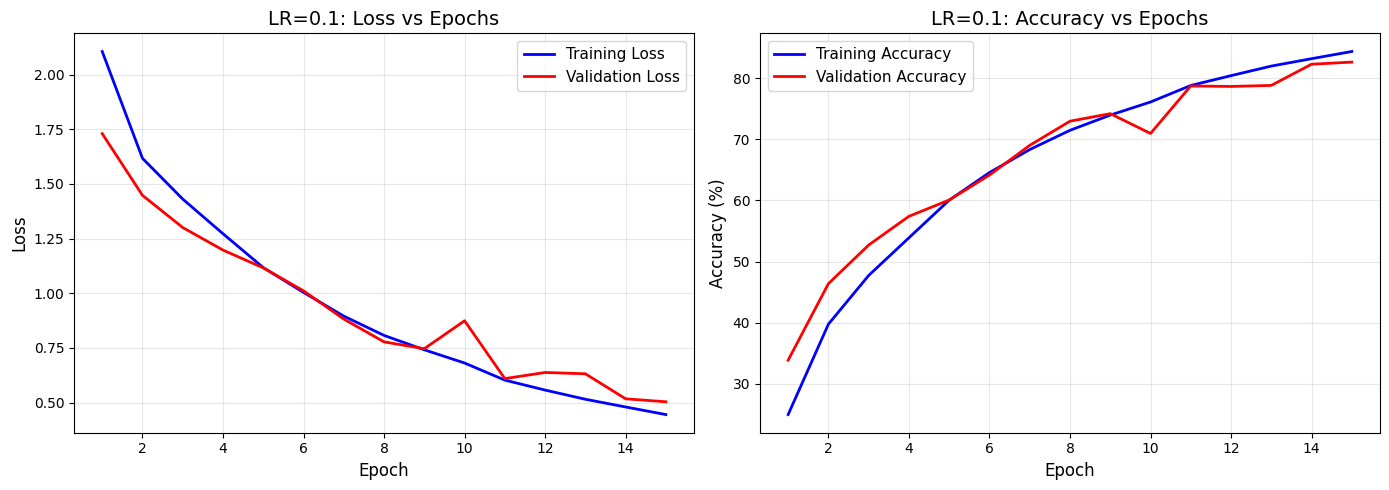

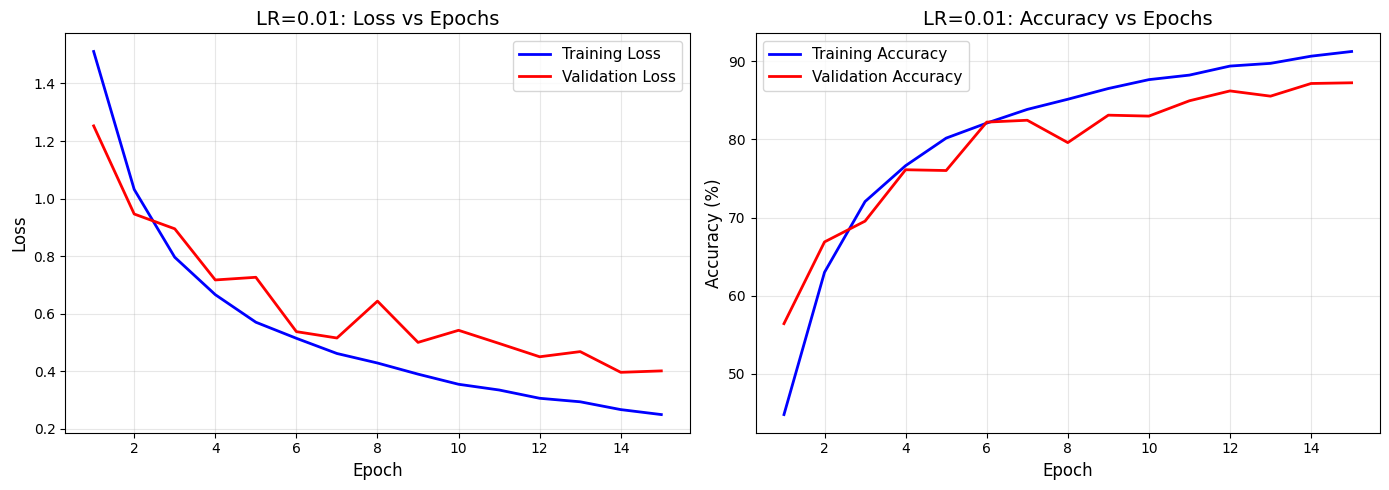

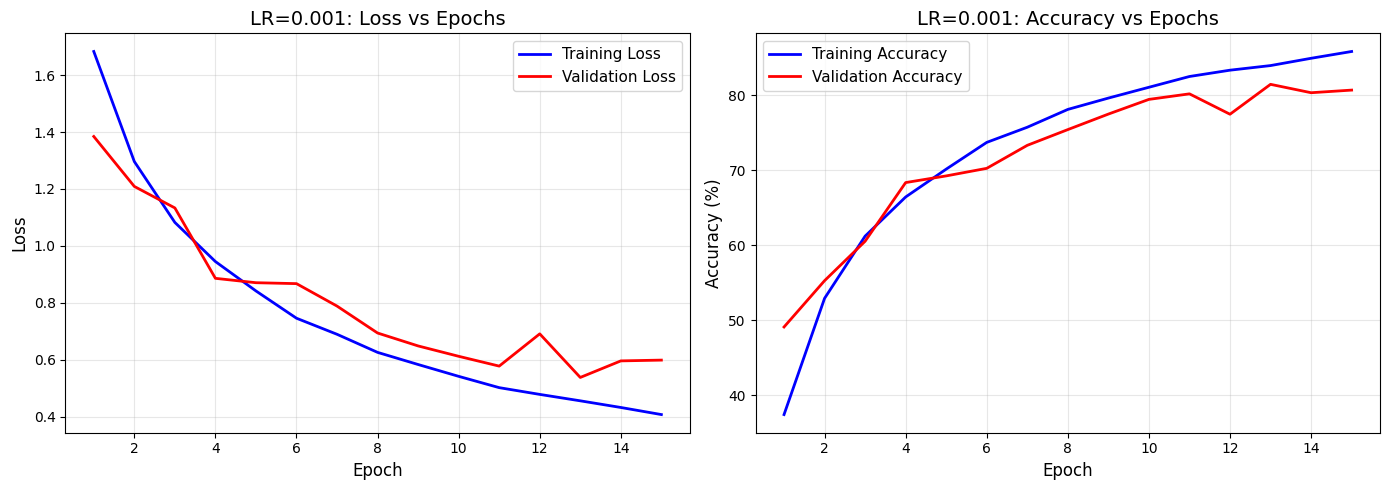

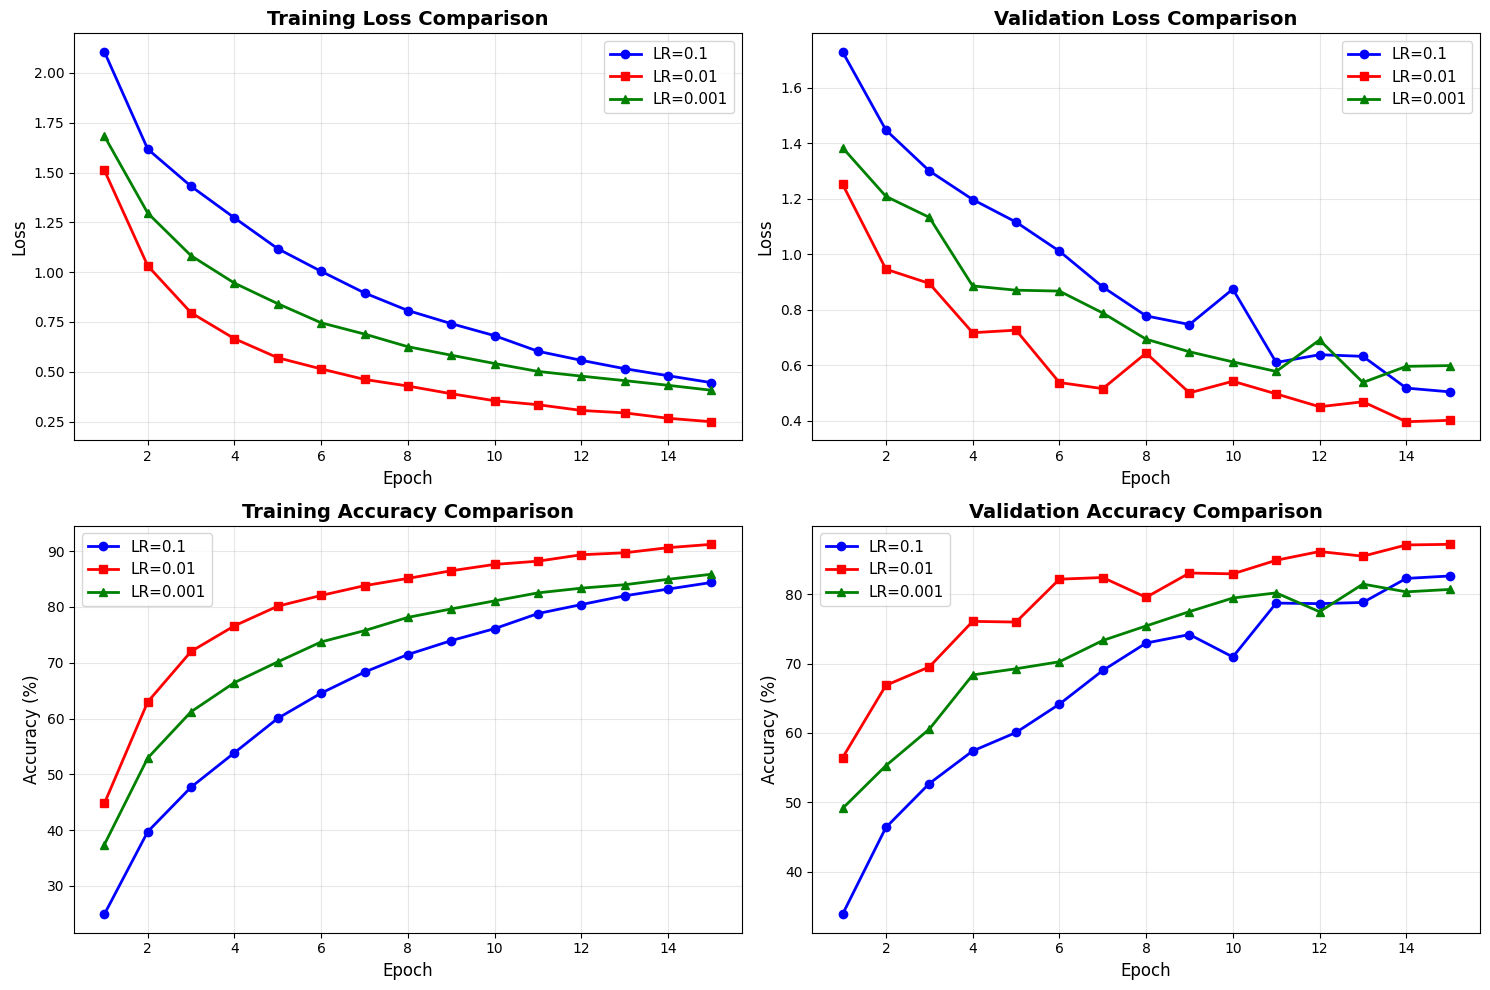


SUMMARY TABLE
Learning Rate   Train Acc    Val Acc      Train Loss   Val Loss    
----------------------------------------------------------------------
0.1                  84.39%      82.66%     0.4455     0.5040
0.01                 91.23%      87.23%     0.2494     0.4012
0.001                85.87%      80.72%     0.4073     0.5986

BEST LEARNING RATE: 0.01 (Validation Accuracy: 87.23%)


In [17]:
# Cell 8: Section 3 - Visualization and Analysis
print("\n" + "="*70)
print("SECTION 3: RESULTS COMPARISON")
print("="*70)

# Individual plots
plot_curves(train_losses_lr01, val_losses_lr01, train_accs_lr01, val_accs_lr01, 
           "LR=0.1: ")

plot_curves(train_losses_lr001, val_losses_lr001, train_accs_lr001, val_accs_lr001, 
           "LR=0.01: ")

plot_curves(train_losses_lr0001, val_losses_lr0001, train_accs_lr0001, val_accs_lr0001, 
           "LR=0.001: ")

# Comparison plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
epochs_range = range(1, epochs_section3 + 1)

# Training Loss
ax1.plot(epochs_range, train_losses_lr01, 'b-', label='LR=0.1', linewidth=2, marker='o')
ax1.plot(epochs_range, train_losses_lr001, 'r-', label='LR=0.01', linewidth=2, marker='s')
ax1.plot(epochs_range, train_losses_lr0001, 'g-', label='LR=0.001', linewidth=2, marker='^')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Validation Loss
ax2.plot(epochs_range, val_losses_lr01, 'b-', label='LR=0.1', linewidth=2, marker='o')
ax2.plot(epochs_range, val_losses_lr001, 'r-', label='LR=0.01', linewidth=2, marker='s')
ax2.plot(epochs_range, val_losses_lr0001, 'g-', label='LR=0.001', linewidth=2, marker='^')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Training Accuracy
ax3.plot(epochs_range, train_accs_lr01, 'b-', label='LR=0.1', linewidth=2, marker='o')
ax3.plot(epochs_range, train_accs_lr001, 'r-', label='LR=0.01', linewidth=2, marker='s')
ax3.plot(epochs_range, train_accs_lr0001, 'g-', label='LR=0.001', linewidth=2, marker='^')
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Accuracy (%)', fontsize=12)
ax3.set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Validation Accuracy
ax4.plot(epochs_range, val_accs_lr01, 'b-', label='LR=0.1', linewidth=2, marker='o')
ax4.plot(epochs_range, val_accs_lr001, 'r-', label='LR=0.01', linewidth=2, marker='s')
ax4.plot(epochs_range, val_accs_lr0001, 'g-', label='LR=0.001', linewidth=2, marker='^')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('section3_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(f"{'Learning Rate':<15} {'Train Acc':<12} {'Val Acc':<12} {'Train Loss':<12} {'Val Loss':<12}")
print("-"*70)
print(f"{'0.1':<15} {train_accs_lr01[-1]:>10.2f}% {val_accs_lr01[-1]:>10.2f}% "
      f"{train_losses_lr01[-1]:>10.4f} {val_losses_lr01[-1]:>10.4f}")
print(f"{'0.01':<15} {train_accs_lr001[-1]:>10.2f}% {val_accs_lr001[-1]:>10.2f}% "
      f"{train_losses_lr001[-1]:>10.4f} {val_losses_lr001[-1]:>10.4f}")
print(f"{'0.001':<15} {train_accs_lr0001[-1]:>10.2f}% {val_accs_lr0001[-1]:>10.2f}% "
      f"{train_losses_lr0001[-1]:>10.4f} {val_losses_lr0001[-1]:>10.4f}")

# Determine best learning rate
val_accs_section3 = [val_accs_lr01[-1], val_accs_lr001[-1], val_accs_lr0001[-1]]
best_lr_idx = np.argmax(val_accs_section3)
best_lr_list = [0.1, 0.01, 0.001]
best_lr = best_lr_list[best_lr_idx]

print(f"\n{'='*70}")
print(f"BEST LEARNING RATE: {best_lr} (Validation Accuracy: {val_accs_section3[best_lr_idx]:.2f}%)")
print(f"{'='*70}")

In [10]:
# Cell 9: Section 4 - Constant LR for 300 epochs
print("\n" + "="*70)
print("SECTION 4: LEARNING RATE SCHEDULE")
print("="*70)
print("\n[Experiment 1/2] Constant Learning Rate for 300 epochs")
print(f"Using best LR from Section 3: {best_lr}")
print("-"*70)

epochs_section4 = 300

net_constant = ResNet18().to(device)
optimizer_constant = optim.SGD(net_constant.parameters(), lr=best_lr, 
                               momentum=0.9, weight_decay=0)

train_losses_constant = []
val_losses_constant = []
train_accs_constant = []
val_accs_constant = []

start_time = time.time()

for epoch in range(1, epochs_section4 + 1):
    train_loss, train_acc = train_epoch(epoch, net_constant, criterion, trainloader, 
                                       optimizer_constant, device)
    val_loss, val_acc = evaluate(net_constant, criterion, valloader, device, 
                                 desc=f'Epoch {epoch} [Val]')
    
    train_losses_constant.append(train_loss)
    val_losses_constant.append(val_loss)
    train_accs_constant.append(train_acc)
    val_accs_constant.append(val_acc)
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Save checkpoint every 100 epochs
    if epoch % 100 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': net_constant.state_dict(),
            'optimizer_state_dict': optimizer_constant.state_dict(),
            'train_losses': train_losses_constant,
            'val_losses': val_losses_constant,
            'train_accs': train_accs_constant,
            'val_accs': val_accs_constant,
        }, f'checkpoint_constant_epoch{epoch}.pth')
        print(f"  → Checkpoint saved at epoch {epoch}")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Final Results (Constant LR={best_lr}):")
print(f"  Training   -> Loss: {train_losses_constant[-1]:.4f}, Accuracy: {train_accs_constant[-1]:.2f}%")
print(f"  Validation -> Loss: {val_losses_constant[-1]:.4f}, Accuracy: {val_accs_constant[-1]:.2f}%")


SECTION 4: LEARNING RATE SCHEDULE

[Experiment 1/2] Constant Learning Rate for 300 epochs
Using best LR from Section 3: 0.01
----------------------------------------------------------------------


Epoch 1 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.53it/s, loss=1.444, acc=50.85%]


Epoch   1: Train Loss: 1.5063, Train Acc: 45.04%, Val Loss: 1.4444, Val Acc: 50.85%


Epoch 50 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.72it/s, loss=0.483, acc=90.47%]


Epoch  50: Train Loss: 0.0424, Train Acc: 98.53%, Val Loss: 0.4825, Val Acc: 90.47%


...

Epoch 200: Train Loss: 0.0033, Train Acc: 99.89%, Val Loss: 0.6303, Val Acc: 91.99%
  → Checkpoint saved at epoch 200


Epoch 250 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.51it/s, loss=0.558, acc=92.34%]


Epoch 250: Train Loss: 0.0028, Train Acc: 99.93%, Val Loss: 0.5578, Val Acc: 92.34%


Epoch 300 [Val]: 100%|██████████| 40/40 [00:01<00:00, 35.85it/s, loss=0.641, acc=92.28%]


Epoch 300: Train Loss: 0.0017, Train Acc: 99.94%, Val Loss: 0.6411, Val Acc: 92.28%
  → Checkpoint saved at epoch 300

Training completed in 53.7 minutes
Final Results (Constant LR=0.01):
  Training   -> Loss: 0.0017, Accuracy: 99.94%
  Validation -> Loss: 0.6411, Accuracy: 92.28%


In [11]:
# Cell 10: Section 4 - Cosine Annealing for 300 epochs
print("\n[Experiment 2/2] Cosine Annealing for 300 epochs")
print(f"Initial LR: {best_lr}, Final LR: 0.0")
print("-"*70)

net_cosine = ResNet18().to(device)
optimizer_cosine = optim.SGD(net_cosine.parameters(), lr=best_lr, 
                             momentum=0.9, weight_decay=0)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cosine, T_max=epochs_section4)

train_losses_cosine = []
val_losses_cosine = []
train_accs_cosine = []
val_accs_cosine = []
learning_rates = []

start_time = time.time()

for epoch in range(1, epochs_section4 + 1):
    current_lr = optimizer_cosine.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    train_loss, train_acc = train_epoch(epoch, net_cosine, criterion, trainloader, 
                                       optimizer_cosine, device)
    val_loss, val_acc = evaluate(net_cosine, criterion, valloader, device,
                                 desc=f'Epoch {epoch} [Val]')
    
    train_losses_cosine.append(train_loss)
    val_losses_cosine.append(val_loss)
    train_accs_cosine.append(train_acc)
    val_accs_cosine.append(val_acc)
    
    scheduler_cosine.step()
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}: LR: {current_lr:.6f}, Train Loss: {train_loss:.4f}, "
              f"Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Save checkpoint every 100 epochs
    if epoch % 100 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': net_cosine.state_dict(),
            'optimizer_state_dict': optimizer_cosine.state_dict(),
            'scheduler_state_dict': scheduler_cosine.state_dict(),
            'train_losses': train_losses_cosine,
            'val_losses': val_losses_cosine,
            'train_accs': train_accs_cosine,
            'val_accs': val_accs_cosine,
            'learning_rates': learning_rates,
        }, f'checkpoint_cosine_epoch{epoch}.pth')
        print(f"  → Checkpoint saved at epoch {epoch}")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Final Results (Cosine Annealing):")
print(f"  Training   -> Loss: {train_losses_cosine[-1]:.4f}, Accuracy: {train_accs_cosine[-1]:.2f}%")
print(f"  Validation -> Loss: {val_losses_cosine[-1]:.4f}, Accuracy: {val_accs_cosine[-1]:.2f}%")


[Experiment 2/2] Cosine Annealing for 300 epochs
Initial LR: 0.01, Final LR: 0.0
----------------------------------------------------------------------


Epoch 1 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.85it/s, loss=1.297, acc=54.09%]


Epoch   1: LR: 0.010000, Train Loss: 1.4959, Train Acc: 44.90%, Val Loss: 1.2970, Val Acc: 54.09%


Epoch 50 [Val]: 100%|██████████| 40/40 [00:01<00:00, 35.39it/s, loss=0.461, acc=90.44%]


Epoch  50: LR: 0.009356, Train Loss: 0.0381, Train Acc: 98.63%, Val Loss: 0.4613, Val Acc: 90.44%


...

Epoch 200: LR: 0.002545, Train Loss: 0.0001, Train Acc: 100.00%, Val Loss: 0.4986, Val Acc: 92.90%
  → Checkpoint saved at epoch 200


Epoch 250 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.31it/s, loss=0.490, acc=92.96%]


Epoch 250: LR: 0.000696, Train Loss: 0.0001, Train Acc: 100.00%, Val Loss: 0.4896, Val Acc: 92.96%


Epoch 300 [Val]: 100%|██████████| 40/40 [00:01<00:00, 34.43it/s, loss=0.489, acc=92.95%]


Epoch 300: LR: 0.000000, Train Loss: 0.0001, Train Acc: 100.00%, Val Loss: 0.4894, Val Acc: 92.95%
  → Checkpoint saved at epoch 300

Training completed in 52.9 minutes
Final Results (Cosine Annealing):
  Training   -> Loss: 0.0001, Accuracy: 100.00%
  Validation -> Loss: 0.4894, Accuracy: 92.95%



SECTION 4: RESULTS VISUALIZATION


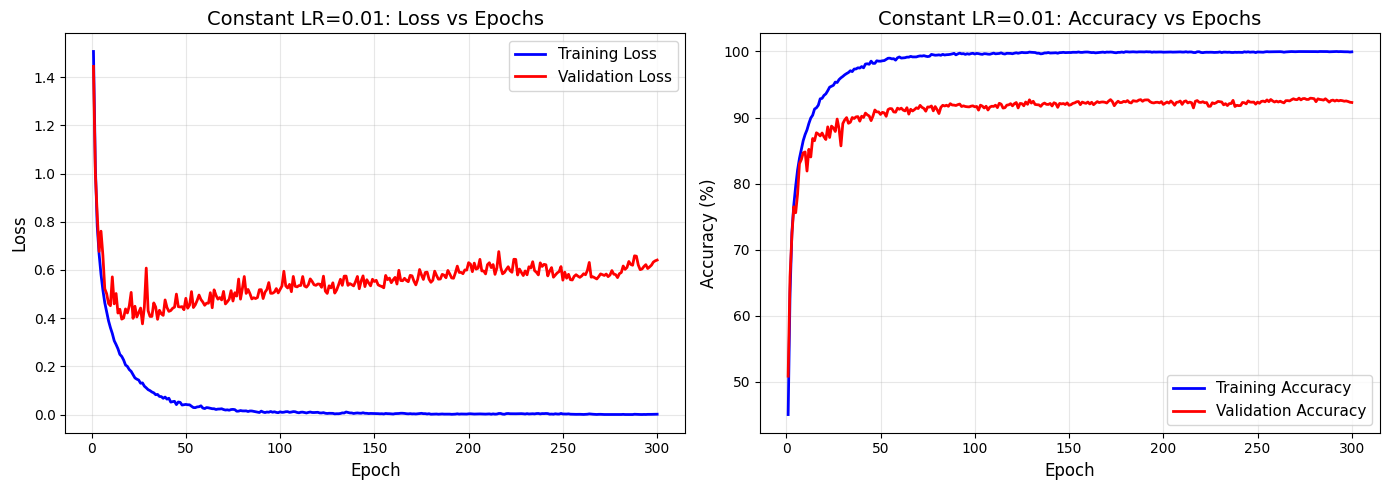

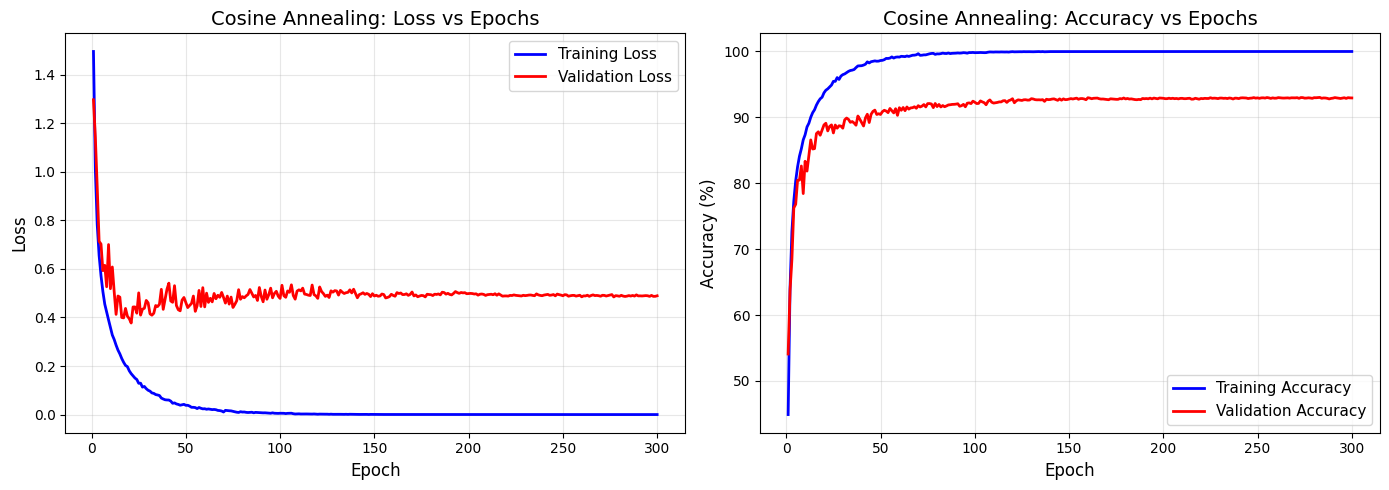

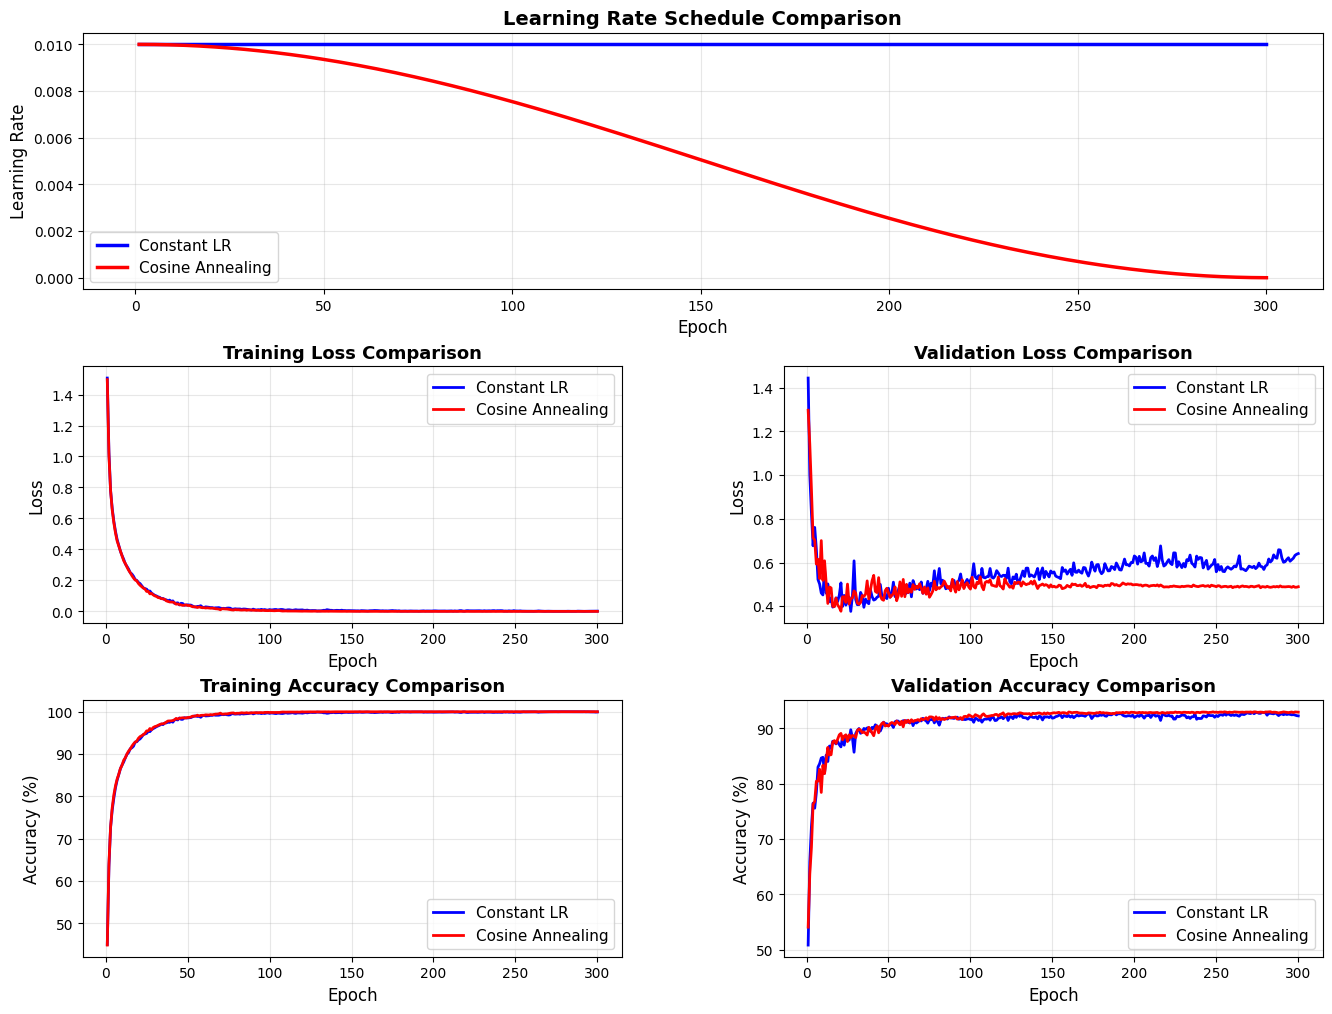


SUMMARY TABLE
Schedule             Train Acc    Val Acc      Train Loss   Val Loss    
----------------------------------------------------------------------
Constant LR               99.94%      92.28%     0.0017     0.6411
Cosine Annealing         100.00%      92.95%     0.0001     0.4894

IMPROVEMENT with Cosine Annealing: +0.67%


In [15]:
# Cell 11: Section 4 - Visualization
print("\n" + "="*70)
print("SECTION 4: RESULTS VISUALIZATION")
print("="*70)

# Individual plots
plot_curves(train_losses_constant, val_losses_constant, train_accs_constant, val_accs_constant,
           f"Constant LR={best_lr}: ")

plot_curves(train_losses_cosine, val_losses_cosine, train_accs_cosine, val_accs_cosine,
           "Cosine Annealing: ")

# Comprehensive comparison
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

epochs_range = range(1, epochs_section4 + 1)

# Learning rate schedule
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(epochs_range, [best_lr]*epochs_section4, 'b-', label='Constant LR', linewidth=2.5)
ax1.plot(epochs_range, learning_rates, 'r-', label='Cosine Annealing', linewidth=2.5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Learning Rate', fontsize=12)
ax1.set_title('Learning Rate Schedule Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Training Loss
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(epochs_range, train_losses_constant, 'b-', label='Constant LR', linewidth=2)
ax2.plot(epochs_range, train_losses_cosine, 'r-', label='Cosine Annealing', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Validation Loss
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(epochs_range, val_losses_constant, 'b-', label='Constant LR', linewidth=2)
ax3.plot(epochs_range, val_losses_cosine, 'r-', label='Cosine Annealing', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Loss', fontsize=12)
ax3.set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Training Accuracy
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(epochs_range, train_accs_constant, 'b-', label='Constant LR', linewidth=2)
ax4.plot(epochs_range, train_accs_cosine, 'r-', label='Cosine Annealing', linewidth=2)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Training Accuracy Comparison', fontsize=13, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

# Validation Accuracy
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(epochs_range, val_accs_constant, 'b-', label='Constant LR', linewidth=2)
ax5.plot(epochs_range, val_accs_cosine, 'r-', label='Cosine Annealing', linewidth=2)
ax5.set_xlabel('Epoch', fontsize=12)
ax5.set_ylabel('Accuracy (%)', fontsize=12)
ax5.set_title('Validation Accuracy Comparison', fontsize=13, fontweight='bold')
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3)

plt.savefig('section4_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(f"{'Schedule':<20} {'Train Acc':<12} {'Val Acc':<12} {'Train Loss':<12} {'Val Loss':<12}")
print("-"*70)
print(f"{'Constant LR':<20} {train_accs_constant[-1]:>10.2f}% {val_accs_constant[-1]:>10.2f}% "
      f"{train_losses_constant[-1]:>10.4f} {val_losses_constant[-1]:>10.4f}")
print(f"{'Cosine Annealing':<20} {train_accs_cosine[-1]:>10.2f}% {val_accs_cosine[-1]:>10.2f}% "
      f"{train_losses_cosine[-1]:>10.4f} {val_losses_cosine[-1]:>10.4f}")

improvement = val_accs_cosine[-1] - val_accs_constant[-1]
print(f"\n{'='*70}")
print(f"IMPROVEMENT with Cosine Annealing: {improvement:+.2f}%")
print(f"{'='*70}")

In [18]:
# Cell 12: Section 5 - Weight Decay = 5e-4
print("\n" + "="*70)
print("SECTION 5: WEIGHT DECAY")
print("="*70)
print("\n[Experiment 1/2] Weight Decay = 5e-4")
print(f"LR: {best_lr}, Schedule: Cosine Annealing")
print("-"*70)

net_wd1 = ResNet18().to(device)
optimizer_wd1 = optim.SGD(net_wd1.parameters(), lr=best_lr, 
                         momentum=0.9, weight_decay=5e-4)
scheduler_wd1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_wd1, T_max=epochs_section4)

train_losses_wd1 = []
val_losses_wd1 = []
train_accs_wd1 = []
val_accs_wd1 = []

start_time = time.time()

for epoch in range(1, epochs_section4 + 1):
    train_loss, train_acc = train_epoch(epoch, net_wd1, criterion, trainloader, 
                                       optimizer_wd1, device)
    val_loss, val_acc = evaluate(net_wd1, criterion, valloader, device,
                                 desc=f'Epoch {epoch} [Val]')
    
    train_losses_wd1.append(train_loss)
    val_losses_wd1.append(val_loss)
    train_accs_wd1.append(train_acc)
    val_accs_wd1.append(val_acc)
    
    scheduler_wd1.step()
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Save checkpoint every 100 epochs
    if epoch % 100 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': net_wd1.state_dict(),
            'optimizer_state_dict': optimizer_wd1.state_dict(),
            'scheduler_state_dict': scheduler_wd1.state_dict(),
            'train_losses': train_losses_wd1,
            'val_losses': val_losses_wd1,
            'train_accs': train_accs_wd1,
            'val_accs': val_accs_wd1,
        }, f'checkpoint_wd5e4_epoch{epoch}.pth')
        print(f"  → Checkpoint saved at epoch {epoch}")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Final Results (WD=5e-4):")
print(f"  Training   -> Loss: {train_losses_wd1[-1]:.4f}, Accuracy: {train_accs_wd1[-1]:.2f}%")
print(f"  Validation -> Loss: {val_losses_wd1[-1]:.4f}, Accuracy: {val_accs_wd1[-1]:.2f}%")


SECTION 5: WEIGHT DECAY

[Experiment 1/2] Weight Decay = 5e-4
LR: 0.01, Schedule: Cosine Annealing
----------------------------------------------------------------------


Epoch 1 [Val]: 100%|██████████| 40/40 [00:01<00:00, 35.75it/s, loss=1.278, acc=56.12%]


Epoch   1: Train Loss: 1.5059, Train Acc: 44.80%, Val Loss: 1.2782, Val Acc: 56.12%


Epoch 50 [Val]: 100%|██████████| 40/40 [00:01<00:00, 35.32it/s, loss=0.384, acc=90.17%]


Epoch  50: Train Loss: 0.0645, Train Acc: 97.75%, Val Loss: 0.3842, Val Acc: 90.17%


...

Epoch 200: Train Loss: 0.0013, Train Acc: 100.00%, Val Loss: 0.2638, Val Acc: 93.93%
  → Checkpoint saved at epoch 200


Epoch 250 [Val]: 100%|██████████| 40/40 [00:01<00:00, 34.53it/s, loss=0.248, acc=94.24%]


Epoch 250: Train Loss: 0.0012, Train Acc: 100.00%, Val Loss: 0.2479, Val Acc: 94.24%


Epoch 300 [Val]: 100%|██████████| 40/40 [00:01<00:00, 35.77it/s, loss=0.248, acc=94.24%]


Epoch 300: Train Loss: 0.0012, Train Acc: 100.00%, Val Loss: 0.2482, Val Acc: 94.24%
  → Checkpoint saved at epoch 300

Training completed in 53.6 minutes
Final Results (WD=5e-4):
  Training   -> Loss: 0.0012, Accuracy: 100.00%
  Validation -> Loss: 0.2482, Accuracy: 94.24%


In [ ]:
# Cell 13: Section 5 - Weight Decay = 1e-2
print("\n[Experiment 2/2] Weight Decay = 1e-2")
print(f"LR: {best_lr}, Schedule: Cosine Annealing")
print("-"*70)

net_wd2 = ResNet18().to(device)
optimizer_wd2 = optim.SGD(net_wd2.parameters(), lr=best_lr, 
                         momentum=0.9, weight_decay=1e-2)
scheduler_wd2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_wd2, T_max=epochs_section4)

train_losses_wd2 = []
val_losses_wd2 = []
train_accs_wd2 = []
val_accs_wd2 = []

start_time = time.time()

for epoch in range(1, epochs_section4 + 1):
    train_loss, train_acc = train_epoch(epoch, net_wd2, criterion, trainloader, 
                                       optimizer_wd2, device)
    val_loss, val_acc = evaluate(net_wd2, criterion, valloader, device,
                                 desc=f'Epoch {epoch} [Val]')
    
    train_losses_wd2.append(train_loss)
    val_losses_wd2.append(val_loss)
    train_accs_wd2.append(train_acc)
    val_accs_wd2.append(val_acc)
    
    scheduler_wd2.step()
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Save checkpoint every 100 epochs
    if epoch % 100 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': net_wd2.state_dict(),
            'optimizer_state_dict': optimizer_wd2.state_dict(),
            'scheduler_state_dict': scheduler_wd2.state_dict(),
            'train_losses': train_losses_wd2,
            'val_losses': val_losses_wd2,
            'train_accs': train_accs_wd2,
            'val_accs': val_accs_wd2,
        }, f'checkpoint_wd1e2_epoch{epoch}.pth')
        print(f"  → Checkpoint saved at epoch {epoch}")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Final Results (WD=1e-2):")
print(f"  Training   -> Loss: {train_losses_wd2[-1]:.4f}, Accuracy: {train_accs_wd2[-1]:.2f}%")
print(f"  Validation -> Loss: {val_losses_wd2[-1]:.4f}, Accuracy: {val_accs_wd2[-1]:.2f}%")


[Experiment 2/2] Weight Decay = 1e-2
LR: 0.01, Schedule: Cosine Annealing
----------------------------------------------------------------------


Epoch 1 [Val]: 100%|██████████| 40/40 [00:01<00:00, 34.55it/s, loss=1.496, acc=49.14%]


Epoch   1: Train Loss: 1.5220, Train Acc: 44.37%, Val Loss: 1.4957, Val Acc: 49.14%


Epoch 50 [Val]: 100%|██████████| 40/40 [00:01<00:00, 36.33it/s, loss=0.694, acc=76.89%]


Epoch  50: Train Loss: 0.4482, Train Acc: 85.35%, Val Loss: 0.6942, Val Acc: 76.89%


...

Epoch 150 [Val]: 100%|██████████| 40/40 [00:01<00:00, 35.47it/s, loss=0.457, acc=85.08%]


Epoch 150: Train Loss: 0.3088, Train Acc: 90.17%, Val Loss: 0.4570, Val Acc: 85.08%


Epoch 200 [Val]: 100%|██████████| 40/40 [00:01<00:00, 34.80it/s, loss=0.452, acc=85.94%]


Epoch 200: Train Loss: 0.1858, Train Acc: 94.69%, Val Loss: 0.4519, Val Acc: 85.94%
  → Checkpoint saved at epoch 200


Epoch 228 [Train]:  65%|██████▌   | 205/313 [00:06<00:03, 33.65it/s, loss=0.101, acc=97.50%]


SECTION 5: RESULTS VISUALIZATION


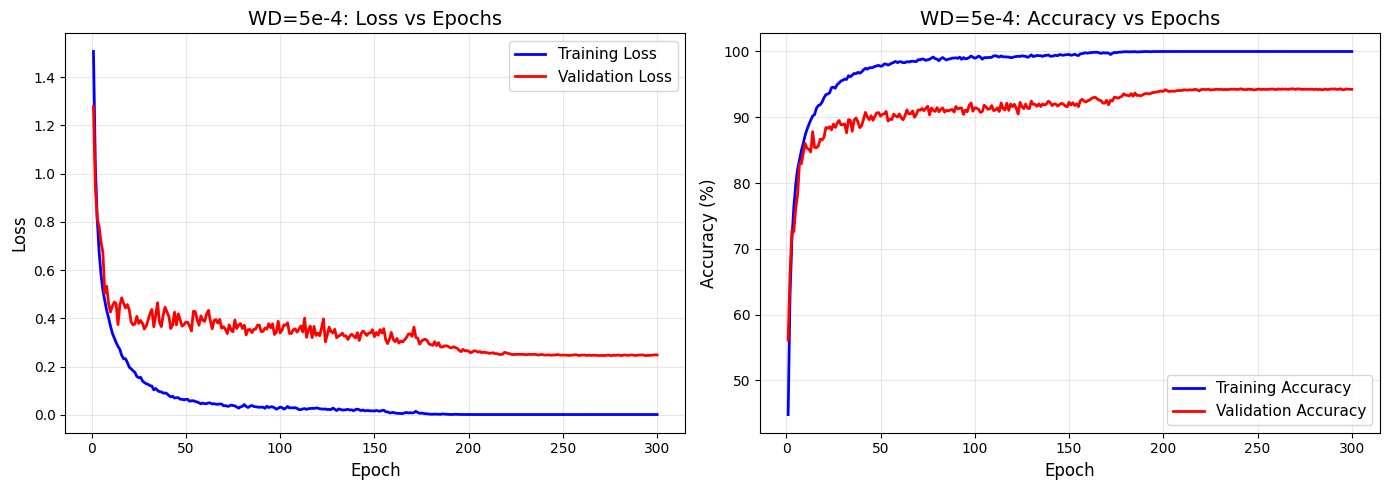

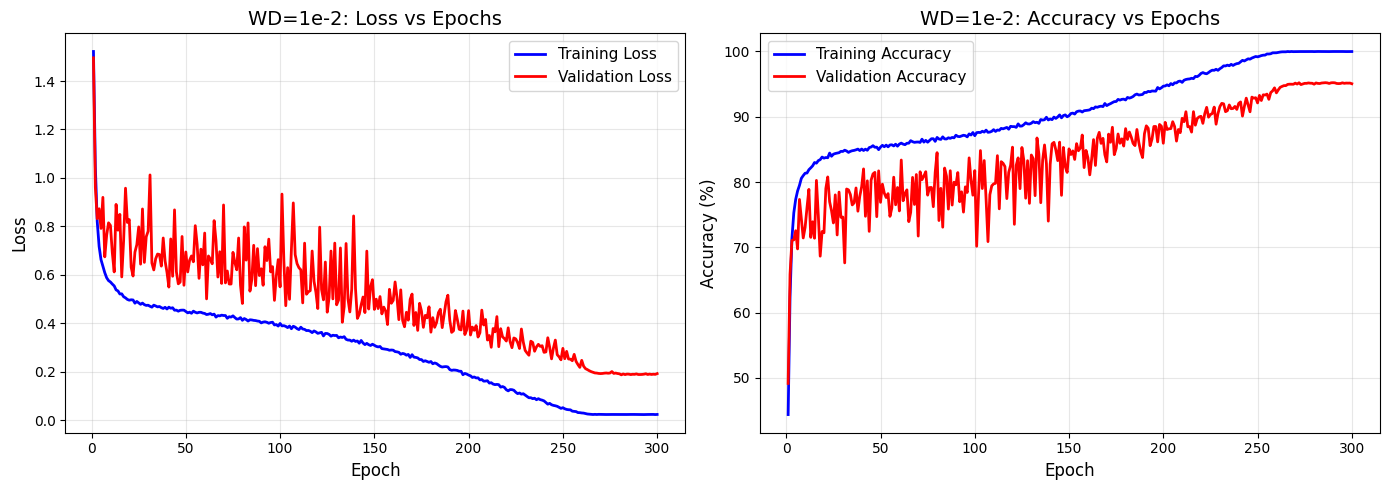

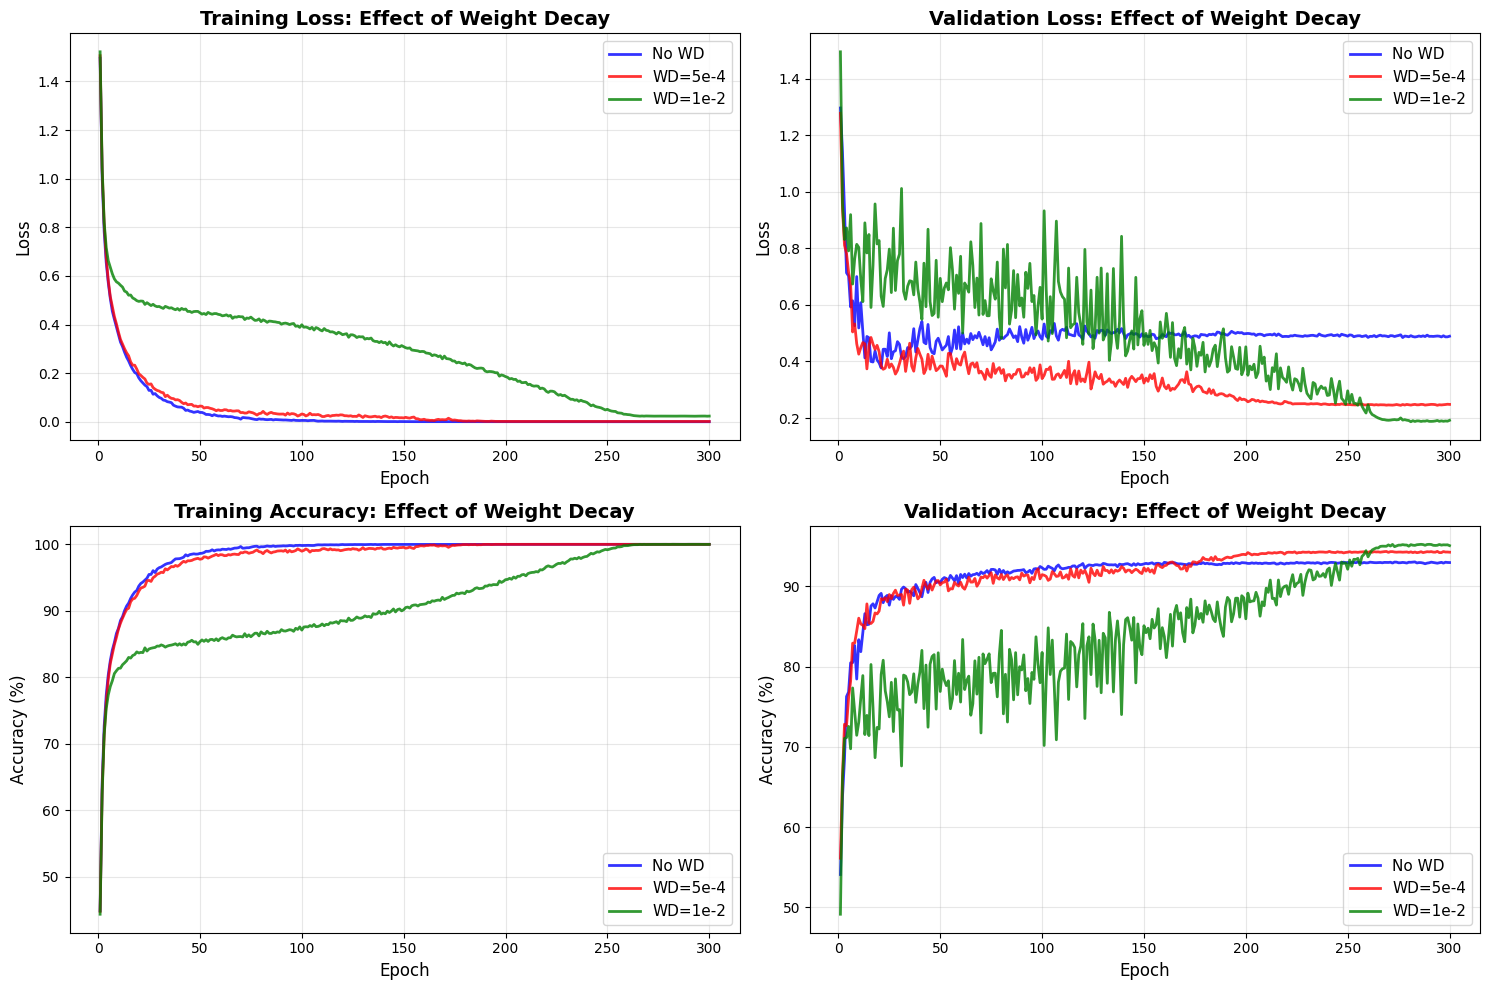


SUMMARY TABLE
Weight Decay    Train Acc    Val Acc      Train Loss   Val Loss    
----------------------------------------------------------------------
0 (No WD)           100.00%      92.95%     0.0001     0.4894
5e-4                100.00%      94.24%     0.0012     0.2482
1e-2                 99.99%      95.06%     0.0233     0.1918

REGULARIZATION EFFECT (Train-Val Gap)
Weight Decay    Overfitting Gap     
----------------------------------------------------------------------
No WD                         7.05%
WD=5e-4                       5.76%
WD=1e-2                       4.93%

Note: Smaller gap indicates better regularization (less overfitting)


In [26]:
# Cell 14: Section 5 - Visualization
print("\n" + "="*70)
print("SECTION 5: RESULTS VISUALIZATION")
print("="*70)

# Individual plots
plot_curves(train_losses_wd1, val_losses_wd1, train_accs_wd1, val_accs_wd1,
           "WD=5e-4: ")

plot_curves(train_losses_wd2, val_losses_wd2, train_accs_wd2, val_accs_wd2,
           "WD=1e-2: ")

# Comprehensive comparison including no weight decay
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
epochs_range = range(1, epochs_section4 + 1)

# Training Loss
ax1.plot(epochs_range, train_losses_cosine, 'b-', label='No WD', linewidth=2, alpha=0.8)
ax1.plot(epochs_range, train_losses_wd1, 'r-', label='WD=5e-4', linewidth=2, alpha=0.8)
ax1.plot(epochs_range, train_losses_wd2, 'g-', label='WD=1e-2', linewidth=2, alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss: Effect of Weight Decay', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Validation Loss
ax2.plot(epochs_range, val_losses_cosine, 'b-', label='No WD', linewidth=2, alpha=0.8)
ax2.plot(epochs_range, val_losses_wd1, 'r-', label='WD=5e-4', linewidth=2, alpha=0.8)
ax2.plot(epochs_range, val_losses_wd2, 'g-', label='WD=1e-2', linewidth=2, alpha=0.8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Validation Loss: Effect of Weight Decay', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Training Accuracy
ax3.plot(epochs_range, train_accs_cosine, 'b-', label='No WD', linewidth=2, alpha=0.8)
ax3.plot(epochs_range, train_accs_wd1, 'r-', label='WD=5e-4', linewidth=2, alpha=0.8)
ax3.plot(epochs_range, train_accs_wd2, 'g-', label='WD=1e-2', linewidth=2, alpha=0.8)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Accuracy (%)', fontsize=12)
ax3.set_title('Training Accuracy: Effect of Weight Decay', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Validation Accuracy
ax4.plot(epochs_range, val_accs_cosine, 'b-', label='No WD', linewidth=2, alpha=0.8)
ax4.plot(epochs_range, val_accs_wd1, 'r-', label='WD=5e-4', linewidth=2, alpha=0.8)
ax4.plot(epochs_range, val_accs_wd2, 'g-', label='WD=1e-2', linewidth=2, alpha=0.8)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Validation Accuracy: Effect of Weight Decay', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('section5_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary and analysis
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(f"{'Weight Decay':<15} {'Train Acc':<12} {'Val Acc':<12} {'Train Loss':<12} {'Val Loss':<12}")
print("-"*70)
print(f"{'0 (No WD)':<15} {train_accs_cosine[-1]:>10.2f}% {val_accs_cosine[-1]:>10.2f}% "
      f"{train_losses_cosine[-1]:>10.4f} {val_losses_cosine[-1]:>10.4f}")
print(f"{'5e-4':<15} {train_accs_wd1[-1]:>10.2f}% {val_accs_wd1[-1]:>10.2f}% "
      f"{train_losses_wd1[-1]:>10.4f} {val_losses_wd1[-1]:>10.4f}")
print(f"{'1e-2':<15} {train_accs_wd2[-1]:>10.2f}% {val_accs_wd2[-1]:>10.2f}% "
      f"{train_losses_wd2[-1]:>10.4f} {val_losses_wd2[-1]:>10.4f}")

# Analyze regularization effect (overfitting gap)
print("\n" + "="*70)
print("REGULARIZATION EFFECT (Train-Val Gap)")
print("="*70)
gap_no_wd = train_accs_cosine[-1] - val_accs_cosine[-1]
gap_wd1 = train_accs_wd1[-1] - val_accs_wd1[-1]
gap_wd2 = train_accs_wd2[-1] - val_accs_wd2[-1]

print(f"{'Weight Decay':<15} {'Overfitting Gap':<20}")
print("-"*70)
print(f"{'No WD':<15} {gap_no_wd:>18.2f}%")
print(f"{'WD=5e-4':<15} {gap_wd1:>18.2f}%")
print(f"{'WD=1e-2':<15} {gap_wd2:>18.2f}%")
print("\nNote: Smaller gap indicates better regularization (less overfitting)")

In [ ]:
#Custom Batch Normalization 

class CustomBatchNorm(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(CustomBatchNorm, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        
        self.weight = nn.Parameter(torch.ones(num_features))    #Gamme
        self.bias = nn.Parameter(torch.zeros(num_features))     #Beta
        
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))
        self.register_buffer('num_batches_tracked', torch.tensor(0, dtype=torch.long))
    def forward(self, x):
        if self.training:
            mean = x.mean(dim=(0, 2, 3), keepdim=False)     #Batch mean
            var = x.var(dim=(0, 2, 3), unbiased=False, keepdim=False)     #Batch variance 
            mean_detached = mean.detach()   #Detaching mean
            var_detached = var.detach()     #Detaching variance
            
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean_detached
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var_detached
                self.num_batches_tracked += 1
            
            mean_detached = mean_detached.view(1, -1, 1, 1)
            var_detached = var_detached.view(1, -1, 1, 1)
            x_normalized = (x - mean_detached) / torch.sqrt(var_detached + self.eps)
            
        else:
            mean = self.running_mean.view(1, -1, 1, 1)
            var = self.running_var.view(1, -1, 1, 1)
            x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        
        weight = self.weight.view(1, -1, 1, 1)
        bias = self.bias.view(1, -1, 1, 1)
        out = weight * x_normalized + bias
        
        return out


# Test the custom batch normalization


def test_custom_batchnorm():
    custom_bn = CustomBatchNorm2d(64).to(device)
    test_input = torch.randn(4, 64, 32, 32).to(device)
    
    # Training mode test
    custom_bn.train()
    output_train = custom_bn(test_input)
    print(f"✓ Training mode output shape: {output_train.shape}")
    print(f"  Mean: {output_train.mean().item():.6f}, Std: {output_train.std().item():.6f}")
    
    # Eval mode test
    custom_bn.eval()
    output_eval = custom_bn(test_input)
    print(f"✓ Eval mode output shape: {output_eval.shape}")
    print(f"  Mean: {output_eval.mean().item():.6f}, Std: {output_eval.std().item():.6f}")
    
    # Test gradient flow
    custom_bn.train()
    output_train = custom_bn(test_input)
    loss = output_train.sum()
    loss.backward()
    print(f"✓ Gradient computation successful")
    print(f"  Weight grad norm: {custom_bn.weight.grad.norm().item():.6f}")
    print(f"  Bias grad norm: {custom_bn.bias.grad.norm().item():.6f}")
    
    return True

test_result = test_custom_batchnorm()
if test_result:
    print("\n✓ Custom Batch Normalization implementation verified!")


SECTION 6: CUSTOM BATCH NORMALIZATION

----------------------------------------------------------------------
Testing Custom Batch Normalization Implementation
----------------------------------------------------------------------
✓ Training mode output shape: torch.Size([4, 64, 32, 32])
  Mean: 0.000000, Std: 0.999997
✓ Eval mode output shape: torch.Size([4, 64, 32, 32])
  Mean: -0.000218, Std: 1.001975
✓ Gradient computation successful
  Weight grad norm: 0.000277
  Bias grad norm: 32768.000000

✓ Custom Batch Normalization implementation verified!


In [ ]:
# ResNet-18 with Custom Batch Normalization
class BasicBlockCustomBN(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlockCustomBN, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = CustomBatchNorm(planes)  
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = CustomBatchNorm(planes) 
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes,
                         kernel_size=1, stride=stride, bias=False),
                CustomBatchNorm(self.expansion*planes)  
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNetCustomBN(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNetCustomBN, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = CustomBatchNorm(64) 
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512*block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def ResNet18CustomBN():
    return ResNetCustomBN(BasicBlockCustomBN, [2, 2, 2, 2])


print("✓ ResNet-18 with Custom Batch Normalization architecture defined!")

✓ ResNet-18 with Custom Batch Normalization architecture defined!


In [ ]:
# ResNet-18 with Custom Batch Normalization - LR 0.01, Cosine Annealing, 1e-2

best_weight_decay = 1e-2

net_custom_bn = ResNet18CustomBN().to(device)
optimizer_custom = optim.SGD(net_custom_bn.parameters(), lr=best_lr, momentum=0.9, weight_decay=best_weight_decay)
scheduler_custom = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_custom, T_max=epochs_section4)
train_losses_custom = []
val_losses_custom = []
train_accs_custom = []
val_accs_custom = []
start_time = time.time()

for epoch in range(1, epochs_section4 + 1):
    train_loss, train_acc = train_epoch(epoch, net_custom_bn, criterion, trainloader, optimizer_custom, device)
    val_loss, val_acc = evaluate(net_custom_bn, criterion, valloader, device, desc=f'Epoch {epoch} [Val]')
    
    train_losses_custom.append(train_loss)
    val_losses_custom.append(val_loss)
    train_accs_custom.append(train_acc)
    val_accs_custom.append(val_acc)
    
    scheduler_custom.step()
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    
    if epoch % 100 == 0:                #Checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': net_custom_bn.state_dict(),
            'optimizer_state_dict': optimizer_custom.state_dict(),
            'scheduler_state_dict': scheduler_custom.state_dict(),
            'train_losses': train_losses_custom,
            'val_losses': val_losses_custom,
            'train_accs': train_accs_custom,
            'val_accs': val_accs_custom,
        }, f'checkpoint_custom_bn_epoch{epoch}.pth')
        print(f" Checkpoint at epoch {epoch}")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"\nFinal Results (Custom Batch Normalization):")
print(f"  Training   -> Loss: {train_losses_custom[-1]:.4f}, Accuracy: {train_accs_custom[-1]:.2f}%")
print(f"  Validation -> Loss: {val_losses_custom[-1]:.4f}, Accuracy: {val_accs_custom[-1]:.2f}%")

torch.save({
    'model_state_dict': net_custom_bn.state_dict(),
    'config': {
        'lr': best_lr,
        'weight_decay': best_weight_decay,
        'epochs': epochs_section4
    },
    'train_acc': train_accs_custom[-1],
    'val_acc': val_accs_custom[-1],
}, 'model_custom_bn_final.pth')
print("\nModel saved.")


----------------------------------------------------------------------
Training ResNet-18 with Custom Batch Normalization
----------------------------------------------------------------------

Best configuration from previous sections:
  Cosine + WD=1e-2: Val Acc = 95.06%

Training Configuration:
  Learning Rate: 0.01
  Weight Decay: 0.01
  Schedule: Cosine Annealing
  Epochs: 300
----------------------------------------------------------------------


Epoch 1 [Val]: 100%|██████████| 40/40 [00:01<00:00, 34.27it/s, loss=2.041, acc=23.98%]


Epoch   1: Train Loss: 1.8090, Train Acc: 32.28%, Val Loss: 2.0415, Val Acc: 23.98%


Epoch 50 [Val]: 100%|██████████| 40/40 [00:01<00:00, 34.03it/s, loss=5.238, acc=9.89%] 


Epoch  50: Train Loss: 1.9005, Train Acc: 27.97%, Val Loss: 5.2385, Val Acc: 9.89%


...

Epoch 200: Train Loss: 1.9033, Train Acc: 27.84%, Val Loss: 3.2256, Val Acc: 10.11%
  → Checkpoint saved at epoch 200


Epoch 250 [Val]: 100%|██████████| 40/40 [00:01<00:00, 34.16it/s, loss=1.957, acc=26.38%]


Epoch 250: Train Loss: 1.9136, Train Acc: 27.69%, Val Loss: 1.9566, Val Acc: 26.38%


Epoch 300 [Val]: 100%|██████████| 40/40 [00:01<00:00, 33.74it/s, loss=1.888, acc=29.24%]


Epoch 300: Train Loss: 1.9145, Train Acc: 27.89%, Val Loss: 1.8881, Val Acc: 29.24%
  → Checkpoint saved at epoch 300

Training completed in 63.6 minutes

Final Results (Custom Batch Normalization):
  Training   -> Loss: 1.9145, Accuracy: 27.89%
  Validation -> Loss: 1.8881, Accuracy: 29.24%

✓ Model saved as 'model_custom_bn_final.pth'



SECTION 6: RESULTS VISUALIZATION


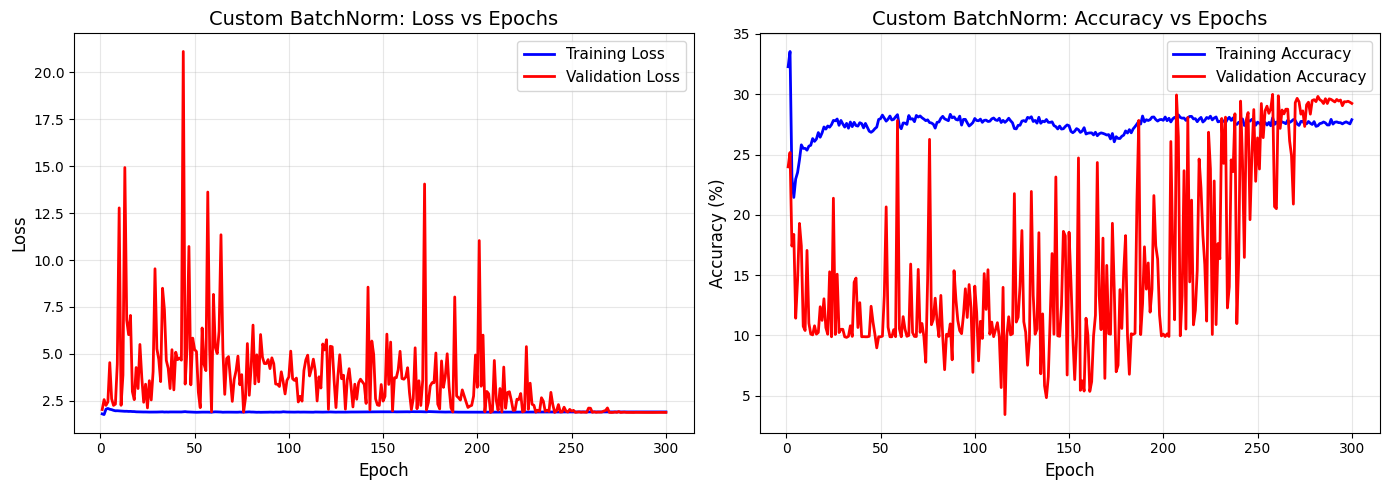

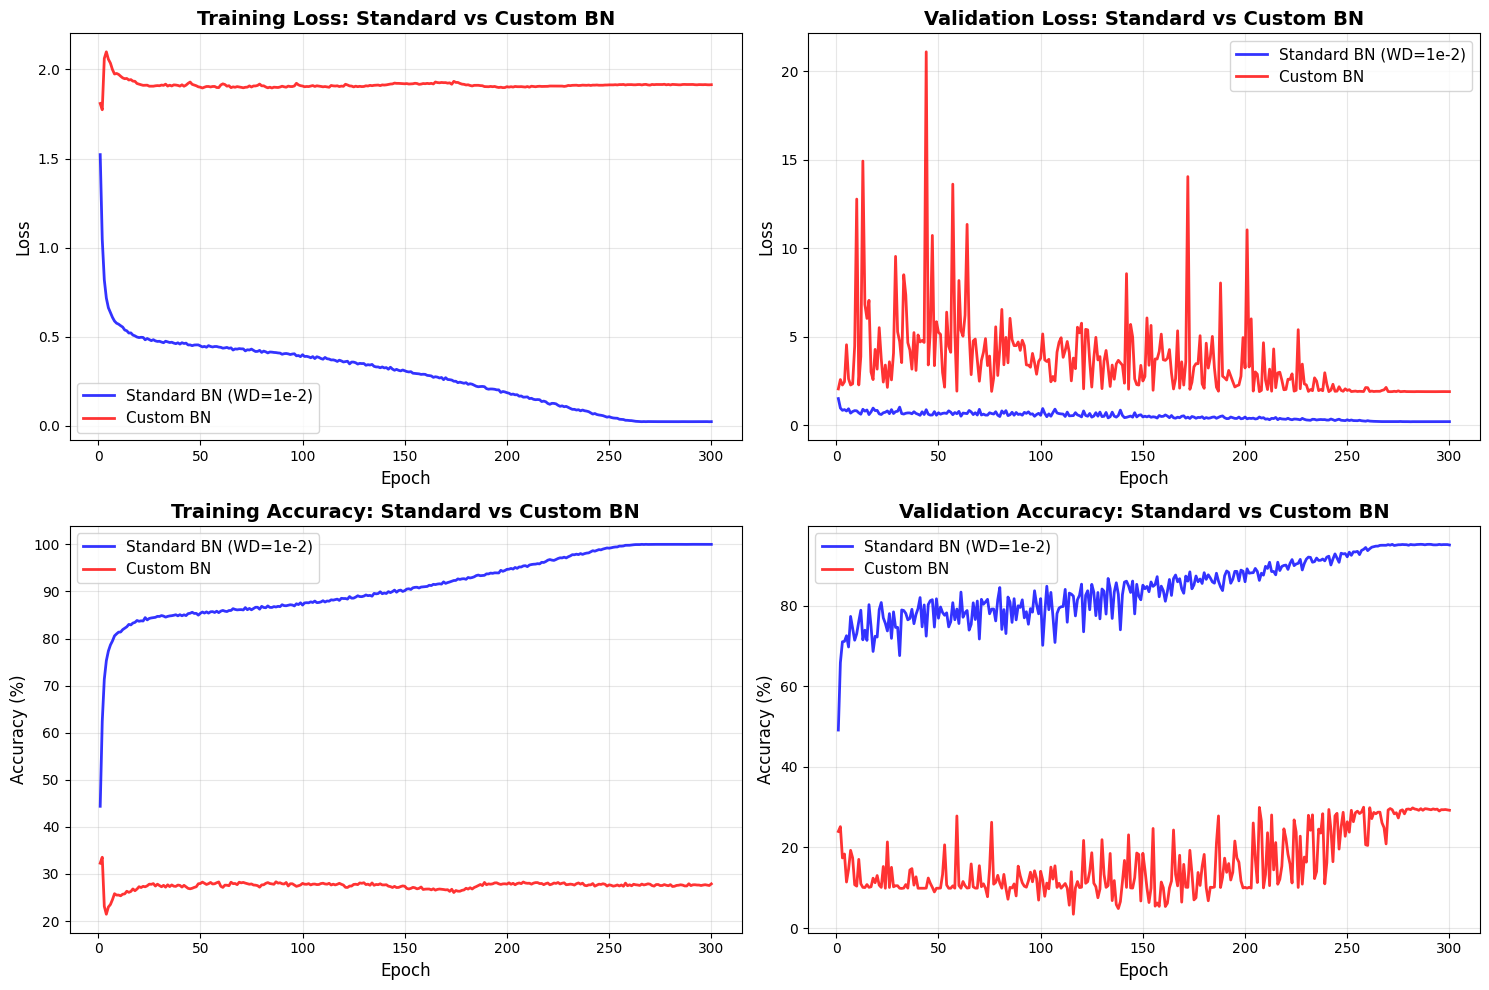


BATCH NORMALIZATION COMPARISON
BN Type              Train Acc    Val Acc      Train Loss   Val Loss    
----------------------------------------------------------------------
Standard BN               99.99%      95.06%     0.0233     0.1918
Custom BN                 27.89%      29.24%     1.9145     1.8881
Difference               -72.11%     -65.82%



In [31]:
# Cell 18: Section 6 - Visualization
print("\n" + "="*70)
print("SECTION 6: RESULTS VISUALIZATION")
print("="*70)

# Plot custom BN results
plot_curves(train_losses_custom, val_losses_custom, train_accs_custom, val_accs_custom,
           "Custom BatchNorm: ")

# Compare with standard BN (best model from Section 5)
if 'WD=5e-4' in best_config_name:
    best_train_losses = train_losses_wd1
    best_val_losses = val_losses_wd1
    best_train_accs = train_accs_wd1
    best_val_accs = val_accs_wd1
    comparison_label = "Standard BN (WD=5e-4)"
elif 'WD=1e-2' in best_config_name:
    best_train_losses = train_losses_wd2
    best_val_losses = val_losses_wd2
    best_train_accs = train_accs_wd2
    best_val_accs = val_accs_wd2
    comparison_label = "Standard BN (WD=1e-2)"
else:
    best_train_losses = train_losses_cosine
    best_val_losses = val_losses_cosine
    best_train_accs = train_accs_cosine
    best_val_accs = val_accs_cosine
    comparison_label = "Standard BN (No WD)"


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
epochs_range = range(1, epochs_section4 + 1)

# Training Loss
ax1.plot(epochs_range, best_train_losses, 'b-', label=comparison_label, linewidth=2, alpha=0.8)
ax1.plot(epochs_range, train_losses_custom, 'r-', label='Custom BN', linewidth=2, alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss: Standard vs Custom BN', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Validation Loss
ax2.plot(epochs_range, best_val_losses, 'b-', label=comparison_label, linewidth=2, alpha=0.8)
ax2.plot(epochs_range, val_losses_custom, 'r-', label='Custom BN', linewidth=2, alpha=0.8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Validation Loss: Standard vs Custom BN', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Training Accuracy
ax3.plot(epochs_range, best_train_accs, 'b-', label=comparison_label, linewidth=2, alpha=0.8)
ax3.plot(epochs_range, train_accs_custom, 'r-', label='Custom BN', linewidth=2, alpha=0.8)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Accuracy (%)', fontsize=12)
ax3.set_title('Training Accuracy: Standard vs Custom BN', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Validation Accuracy
ax4.plot(epochs_range, best_val_accs, 'b-', label=comparison_label, linewidth=2, alpha=0.8)
ax4.plot(epochs_range, val_accs_custom, 'r-', label='Custom BN', linewidth=2, alpha=0.8)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Validation Accuracy: Standard vs Custom BN', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('section6_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary comparison
print("\n" + "="*70)
print("BATCH NORMALIZATION COMPARISON")
print("="*70)
print(f"{'BN Type':<20} {'Train Acc':<12} {'Val Acc':<12} {'Train Loss':<12} {'Val Loss':<12}")
print("-"*70)
print(f"{'Standard BN':<20} {best_train_accs[-1]:>10.2f}% {best_val_accs[-1]:>10.2f}% "
      f"{best_train_losses[-1]:>10.4f} {best_val_losses[-1]:>10.4f}")
print(f"{'Custom BN':<20} {train_accs_custom[-1]:>10.2f}% {val_accs_custom[-1]:>10.2f}% "
      f"{train_losses_custom[-1]:>10.4f} {val_losses_custom[-1]:>10.4f}")

diff_train = train_accs_custom[-1] - best_train_accs[-1]
diff_val = val_accs_custom[-1] - best_val_accs[-1]
print(f"{'Difference':<20} {diff_train:>10.2f}% {diff_val:>10.2f}%")

print("\n" + "="*70)

In [34]:
# Cell 19: Model Selection and Test Set Evaluation
print("\n" + "="*70)
print("FINAL MODEL SELECTION AND TEST SET EVALUATION")
print("="*70)

# Collect all models and their validation accuracies
all_models = {
    'Constant LR (No WD)': (net_constant, val_accs_constant[-1]),
    'Cosine Annealing (No WD)': (net_cosine, val_accs_cosine[-1]),
    'Cosine + WD=5e-4': (net_wd1, val_accs_wd1[-1]),
    'Cosine + WD=1e-2': (net_wd2, val_accs_wd2[-1]),
    'Custom BN + Best Config': (net_custom_bn, val_accs_custom[-1])
}

print("\nModel Selection based on Validation Accuracy:")
print("-"*70)
sorted_models = sorted(all_models.items(), key=lambda x: x[1][1], reverse=True)
for rank, (model_name, (_, val_acc)) in enumerate(sorted_models, 1):
    print(f"{rank}. {model_name:<30s}: {val_acc:.2f}%")

# Select best model
best_model_name = sorted_models[0][0]
best_model = sorted_models[0][1][0]
best_model_val_acc = sorted_models[0][1][1]

print(f"\n{'='*70}")
print(f"SELECTED BEST MODEL: {best_model_name}")
print(f"Validation Accuracy: {best_model_val_acc:.2f}%")
print(f"{'='*70}")

# Evaluate on test set (ONLY NOW - as per assignment requirements)
print("\nEvaluating best model on hold-out test set...")
testloader_final = torch.utils.data.DataLoader(testset, batch_size=256, 
                                               shuffle=False, num_workers=2, pin_memory=True)

test_loss, test_acc = evaluate(best_model, criterion, testloader_final, device, 
                               desc='Test Set Evaluation')

print(f"\n{'*'*70}")
print(f"FINAL TEST SET PERFORMANCE")
print(f"{'*'*70}")
print(f"Model: {best_model_name}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"{'*'*70}")

print(f"\nThis test accuracy ({test_acc:.2f}%) represents the expected performance")
print(f"of the trained model on similar unseen images in the future.")

# Save the best model
torch.save({
    'model_name': best_model_name,
    'model_state_dict': best_model.state_dict(),
    'val_acc': best_model_val_acc,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'config': {
        'lr': best_lr,
        'weight_decay': best_weight_decay,
        'epochs': epochs_section4
    }
}, 'best_model_final.pth')
print(f"\n✓ Best model saved as 'best_model_final.pth'")


FINAL MODEL SELECTION AND TEST SET EVALUATION

Model Selection based on Validation Accuracy:
----------------------------------------------------------------------
1. Cosine + WD=1e-2              : 95.06%
2. Cosine + WD=5e-4              : 94.24%
3. Cosine Annealing (No WD)      : 92.95%
4. Constant LR (No WD)           : 92.28%
5. Custom BN + Best Config       : 29.24%

SELECTED BEST MODEL: Cosine + WD=1e-2
Validation Accuracy: 95.06%

Evaluating best model on hold-out test set...


Test Set Evaluation: 100%|██████████| 40/40 [00:01<00:00, 35.42it/s, loss=0.183, acc=95.02%]



**********************************************************************
FINAL TEST SET PERFORMANCE
**********************************************************************
Model: Cosine + WD=1e-2
Test Loss: 0.1833
Test Accuracy: 95.02%
**********************************************************************

This test accuracy (95.02%) represents the expected performance
of the trained model on similar unseen images in the future.

✓ Best model saved as 'best_model_final.pth'


In [35]:
# Cell 20: Comprehensive Summary for Report
print("\n" + "="*70)
print("COMPREHENSIVE SUMMARY FOR REPORT")
print("="*70)

print("\n" + "="*70)
print("SECTION 3: Initial Learning Rate (15 epochs, no WD, no schedule)")
print("="*70)
print(f"{'LR':<10} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-"*70)
print(f"{'0.1':<10} {train_losses_lr01[-1]:<12.4f} {train_accs_lr01[-1]:<12.2f} "
      f"{val_losses_lr01[-1]:<12.4f} {val_accs_lr01[-1]:<12.2f}")
print(f"{'0.01':<10} {train_losses_lr001[-1]:<12.4f} {train_accs_lr001[-1]:<12.2f} "
      f"{val_losses_lr001[-1]:<12.4f} {val_accs_lr001[-1]:<12.2f}")
print(f"{'0.001':<10} {train_losses_lr0001[-1]:<12.4f} {train_accs_lr0001[-1]:<12.2f} "
      f"{val_losses_lr0001[-1]:<12.4f} {val_accs_lr0001[-1]:<12.2f}")

print("\n" + "="*70)
print("SECTION 4: Learning Rate Schedule (300 epochs, best LR, no WD)")
print("="*70)
print(f"{'Schedule':<20} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-"*70)
print(f"{'Constant':<20} {train_losses_constant[-1]:<12.4f} {train_accs_constant[-1]:<12.2f} "
      f"{val_losses_constant[-1]:<12.4f} {val_accs_constant[-1]:<12.2f}")
print(f"{'Cosine Annealing':<20} {train_losses_cosine[-1]:<12.4f} {train_accs_cosine[-1]:<12.2f} "
      f"{val_losses_cosine[-1]:<12.4f} {val_accs_cosine[-1]:<12.2f}")

print("\n" + "="*70)
print("SECTION 5: Weight Decay (300 epochs, best LR, cosine schedule)")
print("="*70)
print(f"{'Weight Decay':<20} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-"*70)
print(f"{'0 (No WD)':<20} {train_losses_cosine[-1]:<12.4f} {train_accs_cosine[-1]:<12.2f} "
      f"{val_losses_cosine[-1]:<12.4f} {val_accs_cosine[-1]:<12.2f}")
print(f"{'5e-4':<20} {train_losses_wd1[-1]:<12.4f} {train_accs_wd1[-1]:<12.2f} "
      f"{val_losses_wd1[-1]:<12.4f} {val_accs_wd1[-1]:<12.2f}")
print(f"{'1e-2':<20} {train_losses_wd2[-1]:<12.4f} {train_accs_wd2[-1]:<12.2f} "
      f"{val_losses_wd2[-1]:<12.4f} {val_accs_wd2[-1]:<12.2f}")

print("\n" + "="*70)
print("SECTION 6: Custom Batch Normalization (300 epochs, best config)")
print("="*70)
print(f"{'Batch Norm':<20} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-"*70)
print(f"{'Standard BN':<20} {best_train_losses[-1]:<12.4f} {best_train_accs[-1]:<12.2f} "
      f"{best_val_losses[-1]:<12.4f} {best_val_accs[-1]:<12.2f}")
print(f"{'Custom BN':<20} {train_losses_custom[-1]:<12.4f} {train_accs_custom[-1]:<12.2f} "
      f"{val_losses_custom[-1]:<12.4f} {val_accs_custom[-1]:<12.2f}")

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)
print(f"Best Model: {best_model_name}")
print(f"Validation Accuracy: {best_model_val_acc:.2f}%")
print(f"Test Set Accuracy: {test_acc:.2f}%")
print(f"Test Set Loss: {test_loss:.4f}")
print("="*70)


COMPREHENSIVE SUMMARY FOR REPORT

SECTION 3: Initial Learning Rate (15 epochs, no WD, no schedule)
LR         Train Loss   Train Acc    Val Loss     Val Acc     
----------------------------------------------------------------------
0.1        0.4455       84.39        0.5040       82.66       
0.01       0.2494       91.23        0.4012       87.23       
0.001      0.4073       85.87        0.5986       80.72       

SECTION 4: Learning Rate Schedule (300 epochs, best LR, no WD)
Schedule             Train Loss   Train Acc    Val Loss     Val Acc     
----------------------------------------------------------------------
Constant             0.0017       99.94        0.6411       92.28       
Cosine Annealing     0.0001       100.00       0.4894       92.95       

SECTION 5: Weight Decay (300 epochs, best LR, cosine schedule)
Weight Decay         Train Loss   Train Acc    Val Loss     Val Acc     
----------------------------------------------------------------------
0 (No WD)      

In [36]:
# Cell 21: Export all data for report writing
print("\n" + "="*70)
print("EXPORTING DATA FOR REPORT")
print("="*70)

# Create comprehensive data dictionary
report_data = {
    'section_3': {
        'lr_0.1': {
            'train_loss': float(train_losses_lr01[-1]),
            'train_acc': float(train_accs_lr01[-1]),
            'val_loss': float(val_losses_lr01[-1]),
            'val_acc': float(val_accs_lr01[-1]),
            'all_train_losses': [float(x) for x in train_losses_lr01],
            'all_val_losses': [float(x) for x in val_losses_lr01],
            'all_train_accs': [float(x) for x in train_accs_lr01],
            'all_val_accs': [float(x) for x in val_accs_lr01]
        },
        'lr_0.01': {
            'train_loss': float(train_losses_lr001[-1]),
            'train_acc': float(train_accs_lr001[-1]),
            'val_loss': float(val_losses_lr001[-1]),
            'val_acc': float(val_accs_lr001[-1]),
            'all_train_losses': [float(x) for x in train_losses_lr001],
            'all_val_losses': [float(x) for x in val_losses_lr001],
            'all_train_accs': [float(x) for x in train_accs_lr001],
            'all_val_accs': [float(x) for x in val_accs_lr001]
        },
        'lr_0.001': {
            'train_loss': float(train_losses_lr0001[-1]),
            'train_acc': float(train_accs_lr0001[-1]),
            'val_loss': float(val_losses_lr0001[-1]),
            'val_acc': float(val_accs_lr0001[-1]),
            'all_train_losses': [float(x) for x in train_losses_lr0001],
            'all_val_losses': [float(x) for x in val_losses_lr0001],
            'all_train_accs': [float(x) for x in train_accs_lr0001],
            'all_val_accs': [float(x) for x in val_accs_lr0001]
        },
        'best_lr': float(best_lr)
    },
    'section_4': {
        'constant_lr': {
            'train_loss': float(train_losses_constant[-1]),
            'train_acc': float(train_accs_constant[-1]),
            'val_loss': float(val_losses_constant[-1]),
            'val_acc': float(val_accs_constant[-1])
        },
        'cosine_annealing': {
            'train_loss': float(train_losses_cosine[-1]),
            'train_acc': float(train_accs_cosine[-1]),
            'val_loss': float(val_losses_cosine[-1]),
            'val_acc': float(val_accs_cosine[-1])
        }
    },
    'section_5': {
        'no_wd': {
            'train_loss': float(train_losses_cosine[-1]),
            'train_acc': float(train_accs_cosine[-1]),
            'val_loss': float(val_losses_cosine[-1]),
            'val_acc': float(val_accs_cosine[-1]),
            'overfitting_gap': float(train_accs_cosine[-1] - val_accs_cosine[-1])
        },
        'wd_5e4': {
            'train_loss': float(train_losses_wd1[-1]),
            'train_acc': float(train_accs_wd1[-1]),
            'val_loss': float(val_losses_wd1[-1]),
            'val_acc': float(val_accs_wd1[-1]),
            'overfitting_gap': float(train_accs_wd1[-1] - val_accs_wd1[-1])
        },
        'wd_1e2': {
            'train_loss': float(train_losses_wd2[-1]),
            'train_acc': float(train_accs_wd2[-1]),
            'val_loss': float(val_losses_wd2[-1]),
            'val_acc': float(val_accs_wd2[-1]),
            'overfitting_gap': float(train_accs_wd2[-1] - val_accs_wd2[-1])
        }
    },
    'section_6': {
        'standard_bn': {
            'train_loss': float(best_train_losses[-1]),
            'train_acc': float(best_train_accs[-1]),
            'val_loss': float(best_val_losses[-1]),
            'val_acc': float(best_val_accs[-1])
        },
        'custom_bn': {
            'train_loss': float(train_losses_custom[-1]),
            'train_acc': float(train_accs_custom[-1]),
            'val_loss': float(val_losses_custom[-1]),
            'val_acc': float(val_accs_custom[-1])
        }
    },
    'final_results': {
        'best_model_name': best_model_name,
        'validation_accuracy': float(best_model_val_acc),
        'test_accuracy': float(test_acc),
        'test_loss': float(test_loss)
    }
}

# Save to JSON file
with open('experiment_results.json', 'w') as f:
    json.dump(report_data, f, indent=2)

print("✓ All experimental results saved to 'experiment_results.json'")
print("\nYou can now use this data to write your report!")
print("\nKey findings to discuss in your report:")
print(f"  1. Best initial learning rate: {best_lr}")
print(f"  2. Cosine annealing improved validation accuracy by {val_accs_cosine[-1] - val_accs_constant[-1]:.2f}%")
print(f"  3. Best weight decay configuration: {best_config_name}")
print(f"  4. Final test set accuracy: {test_acc:.2f}%")


EXPORTING DATA FOR REPORT
✓ All experimental results saved to 'experiment_results.json'

You can now use this data to write your report!

Key findings to discuss in your report:
  1. Best initial learning rate: 0.01
  2. Cosine annealing improved validation accuracy by 0.67%
  3. Best weight decay configuration: Cosine + WD=1e-2
  4. Final test set accuracy: 95.02%


In [37]:
# Cell 22: Print Custom BatchNorm Code for Report (Section 6 requirement)
print("\n" + "="*70)
print("CUSTOM BATCH NORMALIZATION CODE FOR REPORT")
print("Include this in your report as required by Section 6")
print("="*70)
print("""
class CustomBatchNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(CustomBatchNorm2d, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        
        # Learnable affine parameters
        self.weight = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))
        
        # Running statistics for inference
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))
        self.register_buffer('num_batches_tracked', 
                           torch.tensor(0, dtype=torch.long))
    
    def forward(self, x):
        # x shape: (N, C, H, W)
        if self.training:
            # Compute batch statistics
            mean = x.mean(dim=(0, 2, 3), keepdim=False)
            var = x.var(dim=(0, 2, 3), unbiased=False, keepdim=False)
            
            # Detach to prevent gradient flow
            mean_detached = mean.detach()
            var_detached = var.detach()
            
            # Update running statistics
            with torch.no_grad():
                self.running_mean = ((1 - self.momentum) * 
                                    self.running_mean + 
                                    self.momentum * mean_detached)
                self.running_var = ((1 - self.momentum) * 
                                   self.running_var + 
                                   self.momentum * var_detached)
                self.num_batches_tracked += 1
            
            # Normalize using detached statistics
            mean_detached = mean_detached.view(1, -1, 1, 1)
            var_detached = var_detached.view(1, -1, 1, 1)
            x_normalized = ((x - mean_detached) / 
                          torch.sqrt(var_detached + self.eps))
        else:
            # Use running statistics during inference
            mean = self.running_mean.view(1, -1, 1, 1)
            var = self.running_var.view(1, -1, 1, 1)
            x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        
        # Apply learnable scale and shift
        weight = self.weight.view(1, -1, 1, 1)
        bias = self.bias.view(1, -1, 1, 1)
        return weight * x_normalized + bias
""")


CUSTOM BATCH NORMALIZATION CODE FOR REPORT
Include this in your report as required by Section 6

class CustomBatchNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(CustomBatchNorm2d, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        # Learnable affine parameters
        self.weight = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))

        # Running statistics for inference
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))
        self.register_buffer('num_batches_tracked', 
                           torch.tensor(0, dtype=torch.long))

    def forward(self, x):
        # x shape: (N, C, H, W)
        if self.training:
            # Compute batch statistics
            mean = x.mean(dim=(0, 2, 3), keepdim=False)
            var 